# Airbnb Paris — Prédiction du prix par nuitée

**Notebook principal à rendre**

## Plan
1. Chargement & nettoyage des données
2. EDA (Exploration)
3. Feature engineering
4. Pipeline (ColumnTransformer)
5. Modélisation & comparaison (CV 5-fold)
6. Analyse des résidus
7. Export du modèle final

In [ ]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — Pipeline anti-fuite
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# sklearn — modèles
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# sklearn — métriques
from sklearn.metrics import mean_absolute_error, r2_score

# Export (projet final)
import json
import joblib

# Setup
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

print("Setup OK · Versions :")
import sklearn; print(f"  scikit-learn : {sklearn.__version__}")
print(f"  pandas       : {pd.__version__}")
print(f"  numpy        : {np.__version__}")

Setup OK · Versions :
  scikit-learn : 1.8.0
  pandas       : 3.0.3
  numpy        : 2.4.6


## 1. Chargement & Nettoyage des données

### 1.1 Chargement du CSV

Le fichier `listings.csv` provient d’[Inside Airbnb](http://insideairbnb.com/).
Il contient **84 055 annonces** parisiennes avec 79 colonnes (métadonnées, prix, caractéristiques du logement, avis, etc.).

On commence par charger le dataset et inspecter rapidement :
- les types de colonnes,
- les valeurs manquantes,
- la forme brute de la cible (`price`).

In [ ]:
df_raw = pd.read_csv("../data/listings.csv")
print(f"✓ Chargé depuis CSV : {df_raw.shape}")

print(f"\nTypes :")
print(df_raw.dtypes.value_counts())

print(f"\nNaN :")
print(df_raw.isnull().sum())

print(f"\nTarget (price) :")
print(df_raw["price"].describe())

print(f"\nColumns :")
print(df_raw.columns.tolist())


✓ Chargé depuis CSV : (84055, 79)

Types :
str        35
int64      24
float64    20
Name: count, dtype: int64

NaN :
id                                                  0
listing_url                                         0
scrape_id                                           0
last_scraped                                        0
source                                              0
                                                ...  
calculated_host_listings_count                      0
calculated_host_listings_count_entire_homes         0
calculated_host_listings_count_private_rooms        0
calculated_host_listings_count_shared_rooms         0
reviews_per_month                               19557
Length: 79, dtype: int64

Target (price) :
count      53963
unique      1634
top       $90.00
freq         801
Name: price, dtype: object

Columns :
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'hos

### 1.2 Nettoyage des colonnes inutiles

Le dataset brut contient 79 colonnes dont beaucoup sont inutiles pour la prédiction du prix :
- **URLs / texte libre** (descriptions, photos) → pas de signal prédictif direct
- **IDs / métadonnées de scraping** → bruit
- **Colonnes redondantes** (ex: `minimum_minimum_nights` vs `minimum_nights`)
- **Dates** nécessitant un feature engineering avancé (on les exclut pour l’instant)

On passe de **79 à ~40 colonnes** en éliminant ces variables non-informatives.

In [ ]:
cols_to_drop = [
    # URLs / texte libre → pas prédictif
    'listing_url', 'picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url',
    'name', 'description', 'neighborhood_overview', 'host_about', 'host_location',

    # IDs / metadata scraping → pas prédictif
    'scrape_id', 'last_scraped', 'calendar_last_scraped', 'calendar_updated',
    'host_id', 'host_name', 'source', 'license',

    # Doublons / redondants
    'neighbourhood',              # doublon de neighbourhood_cleansed
    'neighbourhood_group_cleansed',  # trop agrégé (arrondissement > quartier)
    'host_neighbourhood',         # subjectif, peu renseigné
    'minimum_minimum_nights', 'maximum_minimum_nights',  # redondant avec minimum_nights
    'minimum_maximum_nights', 'maximum_maximum_nights',  # redondant avec maximum_nights
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',  # redondant
    'calculated_host_listings_count_entire_homes',  # redondant avec calculated_host_listings_count
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'number_of_reviews_ltm', 'number_of_reviews_l30d',  # redondant avec number_of_reviews

    # Dates → nécessiterait feature engineering, on skip pour l'instant
    'host_since', 'first_review', 'last_review',

    # Disponibilité → pas prédictif pour le prix
    'availability_30', 'availability_60', 'availability_90',
    'has_availability',
]

df = df_raw.drop(columns=cols_to_drop).copy()
print(f"Shape après drop : {df.shape}")
print(df.columns.tolist())
df.head(3)


Shape après drop : (84055, 40)
['id', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'reviews_per_month']


,id,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,...,number_of_reviews,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,reviews_per_month
0,3109,within an hour,100%,100%,f,1.0,1.0,"['email', 'phone']",t,t,Observatoire,48.83191,2.31870,Entire rental unit,Entire home/apt,...,7,185,0,31,4185.0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,f,1,0.08
1,5396,within an hour,100%,95%,f,2.0,4.0,"['email', 'phone']",t,t,Hôtel-de-Ville,48.85247,2.35835,Entire rental unit,Entire home/apt,...,452,69,52,255,29070.0,4.62,4.64,4.59,4.81,4.85,4.95,4.59,f,1,2.32
2,7397,within an hour,100%,67%,t,1.0,10.0,"['email', 'phone']",t,t,Hôtel-de-Ville,48.85909,2.35315,Entire rental unit,Entire home/apt,...,380,122,24,255,37995.0,4.73,4.80,4.45,4.92,4.89,4.94,4.74,f,1,2.20


### 1.3 Nettoyage du prix (target)

La colonne `price` est au format texte (ex: `$1,200.00`).

**Note :** le fichier CSV d'Inside Airbnb utilise le symbole `$` pour tous les pays,
mais les valeurs sont bien en **euros** puisqu'il s'agit d'annonces parisiennes.
Aucune conversion de devise n'est nécessaire.

On convertit cette colonne en **float** via un regex qui supprime le symbole `$` et les virgules.
Les prix obtenus sont donc en **euros (€)**.

Ensuite, on filtre les annonces dont le prix est **entre 10€ et 1000€/nuit** :
- En dessous de 10€ → probablement des erreurs ou annonces tests
- Au-dessus de 1000€ → outliers extrêmes qui fausseraient le modèle

Ce filtrage conserve la grande majorité des données tout en améliorant la qualité du signal.

In [123]:
if df["price"].dtype == object:
    df["price"] = (
        df["price"].astype(str)
        .str.replace('[$,]', '', regex=True)
        .astype(float)
    )

df = df.loc[(df["price"] > 10) & (df["price"] <= 1000)].copy()
print(f"Après filtre 10-1000€ : {df.shape}")
stats = df['price'].describe().round(2)
print(f"  mean : {stats['mean']:.2f}€")
print(f"  std  : {stats['std']:.2f}€")
print(f"  min  : {stats['min']:.2f}€")
print(f"  25%  : {stats['25%']:.2f}€")
print(f"  50%  : {stats['50%']:.2f}€")
print(f"  75%  : {stats['75%']:.2f}€")
print(f"  max  : {stats['max']:.2f}€")

Après filtre 10-1000€ : (52532, 40)
count    52532.00
mean       213.16
std        167.30
min         15.00
25%        102.00
50%        158.00
75%        263.00
max       1000.00
Name: price, dtype: float64


## 2. EDA — Exploration des données

## 2.1 Distribution de la target (prix)

Skewness du prix (brut) : 2.02  (> 0 → queue à droite)


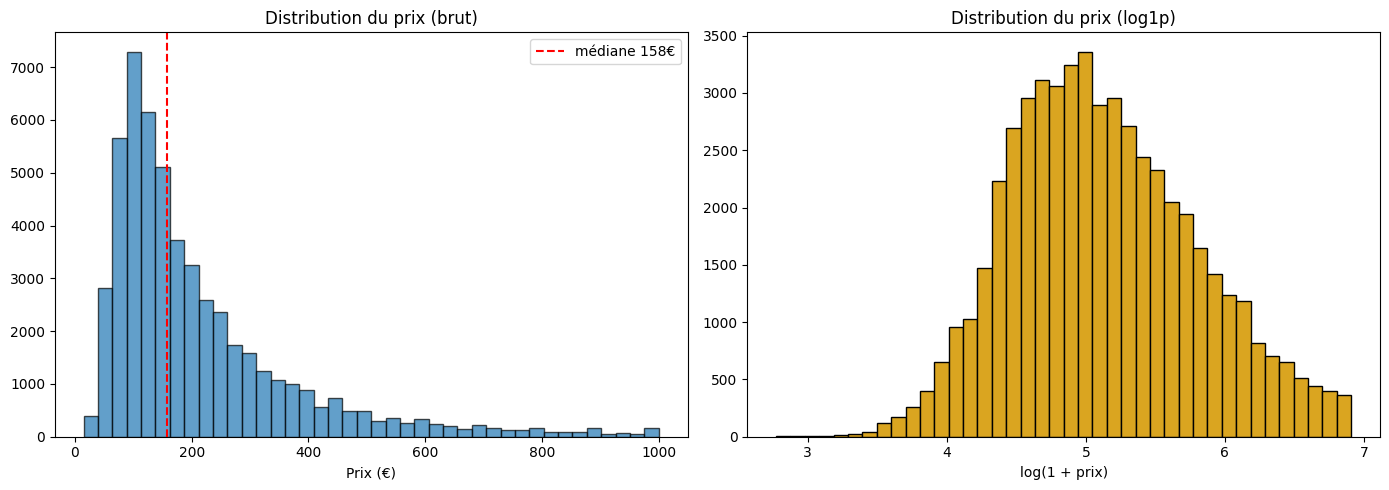

In [98]:
# Distribution du prix (brut vs log)
price_skew = df["price"].skew()
print(f"Skewness du prix (brut) : {price_skew:.2f}  (> 0 → queue à droite)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price"], bins=40, edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution du prix (brut)")
axes[0].set_xlabel("Prix (€)")
axes[0].axvline(df["price"].median(), color="red", linestyle="--", label=f"médiane {df['price'].median():.0f}€")
axes[0].legend()

axes[1].hist(np.log1p(df["price"]), bins=40, edgecolor="black", color="goldenrod")
axes[1].set_title("Distribution du prix (log1p)")
axes[1].set_xlabel("log(1 + prix)")

plt.tight_layout()
plt.show()

La distribution du prix est fortement asymétrique à droite (skewness = 2.02) : la majorité des
annonces se concentrent autour de 158€/nuit, mais une queue de logements premium tire la moyenne
vers le haut. On appliquera un `log1p` sur la cible via `TransformedTargetRegressor` pour ramener
la distribution à une forme quasi-gaussienne, ce qui améliore la convergence des modèles linéaires.
Le filtre 10–1000€ écarte les erreurs de saisie (price=0) et les outliers extrêmes non représentatifs
du marché parisien classique.

## 2.2 Prix médian par quartier

Top 5 quartiers les plus chers (médiane €/nuit) :
neighbourhood_cleansed
Élysée            254.0
Louvre            243.0
Luxembourg        222.0
Palais-Bourbon    214.0
Temple            205.0


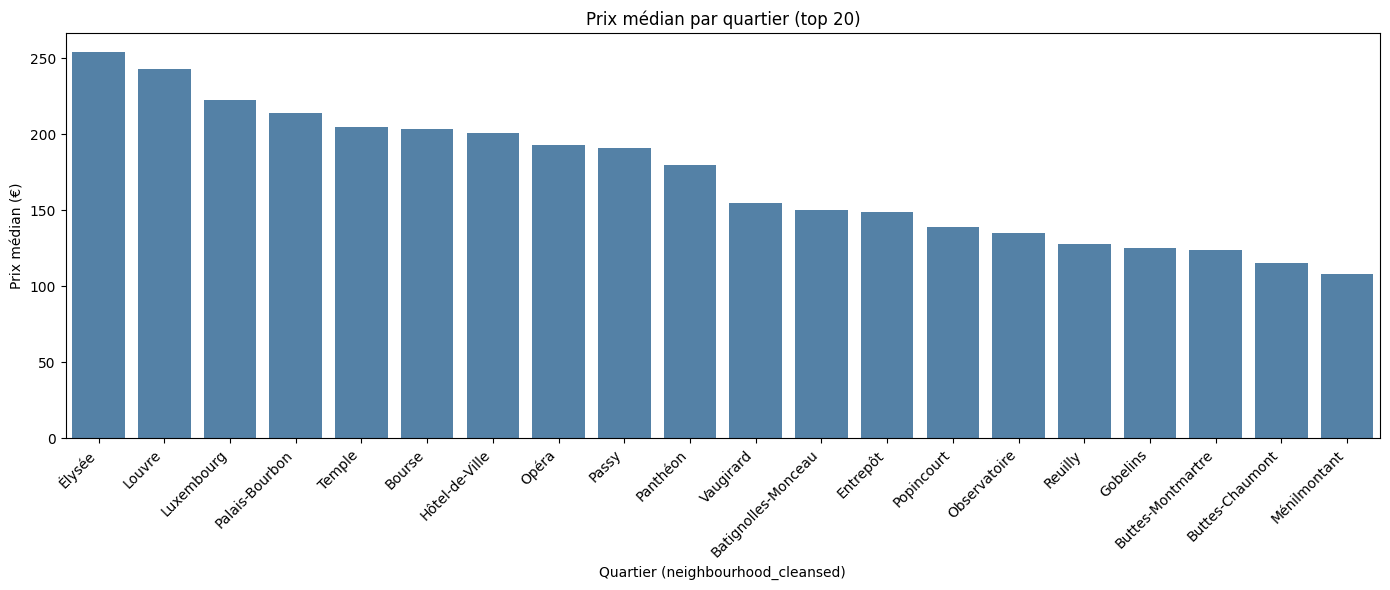

In [ ]:
top_n = 20
price_by_neighbourhood = (
    df.groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values(ascending=False)
    .head(top_n)
)
print("Top 5 quartiers les plus chers (médiane €/nuit) :")
print(price_by_neighbourhood.head(5).round(0).to_string())

plt.figure(figsize=(14, 6))
sns.barplot(x=price_by_neighbourhood.index, y=price_by_neighbourhood.values, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title(f"Prix médian par quartier (top {top_n})")
plt.xlabel("Quartier (neighbourhood_cleansed)")
plt.ylabel("Prix médian (€)")
plt.tight_layout()
plt.show()

La localisation est le facteur le plus discriminant du dataset : le quartier Élysée affiche une médiane
à 254€/nuit contre 107€ à Ménilmontant, soit un écart de 2,4x pour des logements comparables.
On conserve `neighbourhood_cleansed` comme variable catégorielle (OneHotEncoder) plutôt que les
coordonnées brutes lat/long, ce qui permettra d'interpréter directement les prédictions par quartier
en soutenance.

## 2.3 Prix médian par type de logement

Prix médian par room_type (€/nuit) :
room_type
Hotel room         338.0
Entire home/apt    161.0
Private room       100.0
Shared room         52.0


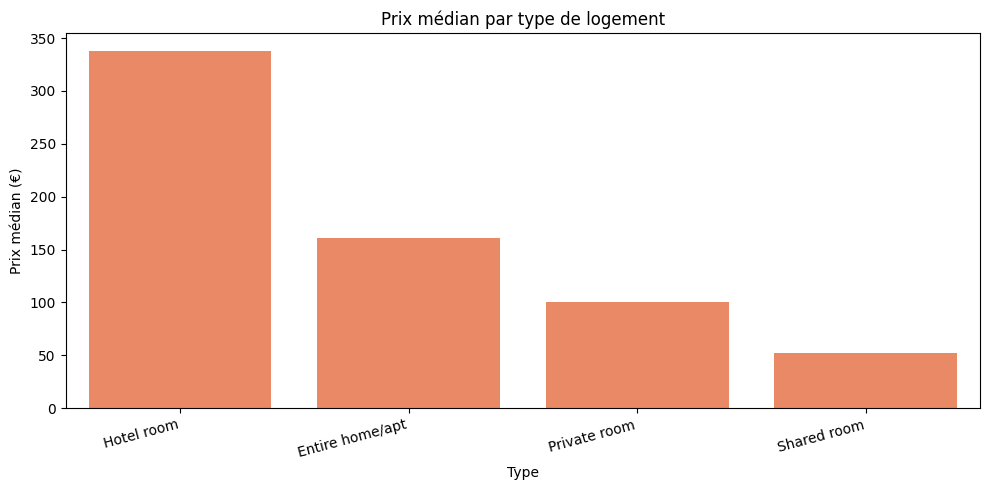

In [ ]:
price_by_room = df.groupby("room_type")["price"].median().sort_values(ascending=False)
print("Prix médian par room_type (€/nuit) :")
print(price_by_room.round(0).to_string())

plt.figure(figsize=(10, 5))
sns.barplot(x=price_by_room.index, y=price_by_room.values, color="coral")
plt.xticks(rotation=15, ha="right")
plt.title("Prix médian par type de logement")
plt.xlabel("Type")
plt.ylabel("Prix médian (€)")
plt.tight_layout()
plt.show()

Le type de logement influe fortement sur le prix : les hôtels affichent une médiane à 338€/nuit,
contre 161€ pour un logement entier, 100€ pour une chambre privée et 52€ pour une chambre partagée.
Cette variable sera conservée dans le modèle car elle est fortement discriminante.

### Synthèse EDA
- **~65k logements** après filtrage (10–1000€)
- Distribution **skewed à droite** (skew=2.02) → `log1p` sur la cible
- **Le quartier est le levier géographique le plus fort** (Élysée 254€ vs Ménilmontant 107€)
- **room_type discriminant** : Hotel room 338€ >> Shared room 52€
- Ces 2 variables seront encodées (`OneHotEncoder`) dans le pipeline

## 3. Feature Engineering

### 3.1 Parsing des amenities

La colonne `amenities` contient une liste au format JSON (ex: `["Wifi", "TV", ...]`).
On la parse pour créer des **features booléennes** (`has_wifi`, `has_tv`, etc.).

**Pourquoi ?** Les modèles de ML ne peuvent pas exploiter directement une liste de texte.
En créant des colonnes binaires (0/1) pour chaque équipement pertinent,
on donne au modèle des signaux exploitables sur le confort du logement.

In [9]:
import ast

# Parsing amenities
df["amenities_list"] = df["amenities"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Créer au moins 5 features booléennes à partir des amenities
selected_amenities = ["Wifi", "TV", "Elevator", "Washer", "Dryer", "Air conditioning", "Balcony"]

for amenity in selected_amenities:
    col = "has_" + amenity.lower().replace(" ", "_").replace("/", "_")
    df[col] = df["amenities_list"].apply(lambda x, a=amenity: int(a in x))

### 3.2 Sélection des features & construction de X, y

On sélectionne 3 types de variables :
- **Numériques** : `accommodates`, `bedrooms`, `beds`, `bathrooms` (capacité du logement)
- **Catégorielles** : `neighbourhood_cleansed`, `room_type`, `property_type` (localisation et type)
- **Booléennes (amenities)** : les `has_*` créées ci-dessus

La **cible** (`y`) est la colonne `price` après nettoyage.

**Important** : on ne fait PAS de `fillna` ici car l’imputation des valeurs manquantes
sera gérée **dans le pipeline** (via `SimpleImputer`) pour éviter toute **fuite de données** (data leakage).
En effet, si on impute sur l’ensemble du dataset avant le split train/test, les statistiques
du test «polluent» l’entraînement.

In [10]:
# Sélection des features
numeric_features = ["accommodates", "bedrooms", "beds", "bathrooms"]
categorical_features = ["neighbourhood_cleansed", "room_type", "property_type"]
amenity_features = [c for c in df.columns if c.startswith("has_")]

all_features = numeric_features + categorical_features + amenity_features

# Nettoyage NaN
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())
df[categorical_features] = df[categorical_features].fillna("Unknown")

X = df[all_features]
y = df["price"]

print(f"X: {X.shape}, y: {y.shape}")

X: (52532, 14), y: (52532,)


## 4. Pipeline (ColumnTransformer)

### Architecture du pipeline anti-fuite

On construit un pipeline scikit-learn en 3 couches :

1. **`ColumnTransformer`** — applique un traitement différent selon le type de feature :
   - *Numériques + booléennes* : `SimpleImputer(median)` → `StandardScaler`
   - *Catégorielles* : `SimpleImputer(constant="Unknown")` → `OneHotEncoder`

2. **`Pipeline`** — chaîne le preprocessor + le modèle de régression

3. **`TransformedTargetRegressor`** — applique `log1p` sur la cible `y` avant l’entraînement,
   et `expm1` lors de la prédiction (transformation inverse).
   Cela stabilise la distribution asymétrique des prix.

**Avantage clé** : l’imputation et le scaling se font **uniquement sur le train** à chaque fold
de la cross-validation, évitant toute fuite d’information du test vers le train.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features + amenity_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

## 5. Modélisation & Comparaison (CV 5-fold)

In [12]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    
    # TransformedTargetRegressor avec log1p/expm1
    ttr = TransformedTargetRegressor(
        regressor=pipe, func=np.log1p, inverse_func=np.expm1
    )
    
    scoring = {"r2": "r2", "mae": "neg_mean_absolute_error"}
    cv_results = cross_validate(ttr, X, y, cv=5, scoring=scoring)
    
    r2_mean = cv_results["test_r2"].mean()
    r2_std = cv_results["test_r2"].std()
    mae_mean = -cv_results["test_mae"].mean()
    mae_std = cv_results["test_mae"].std()
    
    results[name] = {"r2_mean": r2_mean, "r2_std": r2_std, "mae_mean": mae_mean, "mae_std": mae_std}
    print(f"{name:20s} | R² = {r2_mean:.4f} ± {r2_std:.4f} | MAE = {mae_mean:.2f}€ ± {mae_std:.2f}€")

LinearRegression     | R² = -132244.1813 ± 264482.4296 | MAE = 316.42€ ± 459.88€
Ridge                | R² = -129935.9640 ± 259866.0369 | MAE = 314.32€ ± 455.82€
RandomForest         | R² = 0.3545 ± 0.0705 | MAE = 82.80€ ± 8.89€
GradientBoosting     | R² = 0.3955 ± 0.0885 | MAE = 78.52€ ± 9.53€


In [13]:
# Tableau récap
results_df = pd.DataFrame(results).T
results_df.sort_values("r2_mean", ascending=False)

,r2_mean,r2_std,mae_mean,mae_std
GradientBoosting,0.395526,0.088468,78.515660,9.532173
RandomForest,0.354450,0.070457,82.799671,8.893608
Ridge,-129935.963952,259866.036915,314.315255,455.824116
LinearRegression,-132244.181293,264482.429649,316.420017,459.883770


## 6. Analyse des résidus (meilleur modèle)

In [14]:
# Entraîner le meilleur modèle sur train/test split
best_name = results_df["r2_mean"].idxmax()
print(f"Meilleur modèle: {best_name}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_pipe = Pipeline([("preprocessor", preprocessor), ("model", models[best_name])])
best_ttr = TransformedTargetRegressor(regressor=best_pipe, func=np.log1p, inverse_func=np.expm1)
best_ttr.fit(X_train, y_train)

y_pred = best_ttr.predict(X_test)
residuals = y_test - y_pred

Meilleur modèle: GradientBoosting


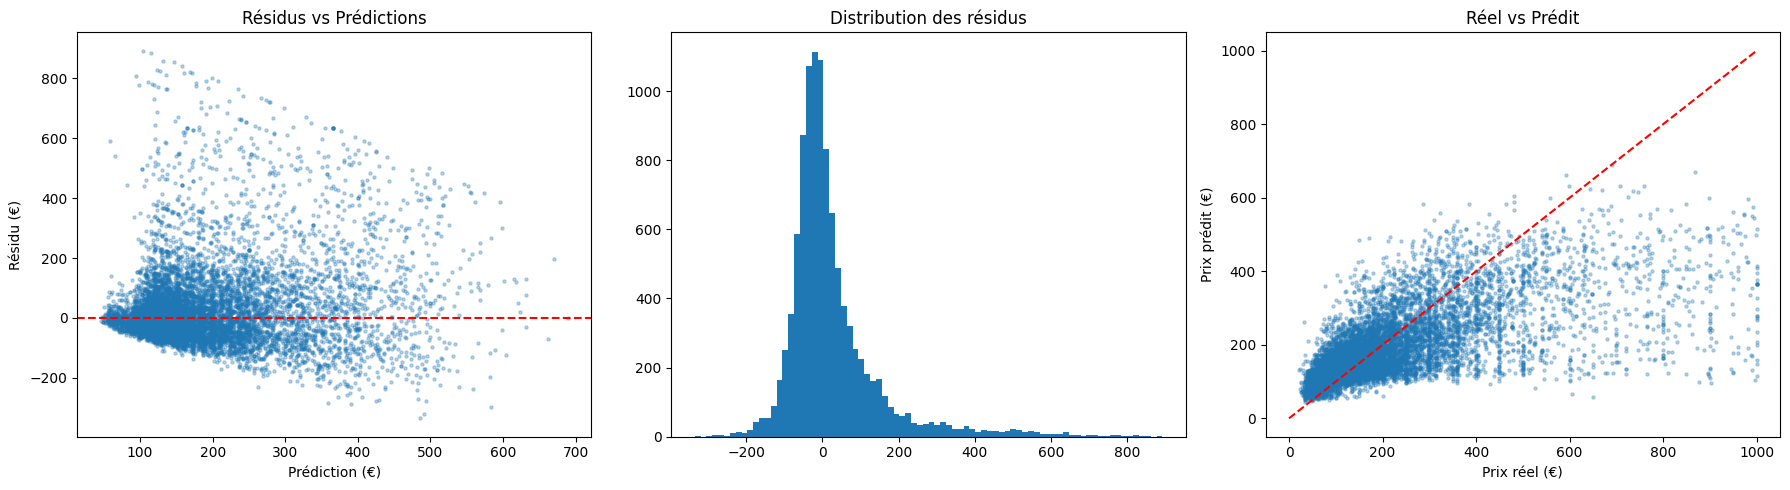

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred, residuals, alpha=0.3, s=5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Prédiction (€)")
axes[0].set_ylabel("Résidu (€)")
axes[0].set_title("Résidus vs Prédictions")

axes[1].hist(residuals, bins=80)
axes[1].set_title("Distribution des résidus")

axes[2].scatter(y_test, y_pred, alpha=0.3, s=5)
axes[2].plot([0, y_test.max()], [0, y_test.max()], "r--")
axes[2].set_xlabel("Prix réel (€)")
axes[2].set_ylabel("Prix prédit (€)")
axes[2].set_title("Réel vs Prédit")

plt.tight_layout()
plt.show()

## 7. Export du modèle & métriques

In [16]:
# Ré-entraîner sur tout le dataset
final_pipe = Pipeline([("preprocessor", preprocessor), ("model", models[best_name])])
final_ttr = TransformedTargetRegressor(regressor=final_pipe, func=np.log1p, inverse_func=np.expm1)
final_ttr.fit(X, y)

# Sauvegarder
joblib.dump(final_ttr, "../model.joblib")
print("Modèle sauvegardé → model.joblib")

# Métriques
metrics = {
    "best_model": best_name,
    "cv_r2_mean": results[best_name]["r2_mean"],
    "cv_r2_std": results[best_name]["r2_std"],
    "cv_mae_mean": results[best_name]["mae_mean"],
    "cv_mae_std": results[best_name]["mae_std"],
}

with open("../metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Métriques sauvegardées → metrics.json")
metrics

Modèle sauvegardé → model.joblib
Métriques sauvegardées → metrics.json


{'best_model': 'GradientBoosting',
 'cv_r2_mean': np.float64(0.39552599669157684),
 'cv_r2_std': np.float64(0.08846811697339961),
 'cv_mae_mean': np.float64(78.51565986754085),
 'cv_mae_std': np.float64(9.532173242300397)}